<a href="https://colab.research.google.com/github/sanjushree99/sanju-codebooster-2026/blob/main/Day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")
print(f"pandas version: {pd.__version__}")
print(f"sqlite3 version: {sqlite3.version}")


All libraries imported successfully!
pandas version: 2.2.2
sqlite3 version: 2.6.0


In [4]:
df = pd.read_csv('student_performance.csv')
print(f"Dataset loaded: {df.shape[0]} students, {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst 3 rows")
df.head(3)

Dataset loaded: 30 students, 13 columns
Columns: ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

First 3 rows


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [5]:
conn = sqlite3.connect('college.db')
cursor = conn.cursor()
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)
cursor.execute("SELECT COUNT(*) FROM STUDENTS")
count = cursor.fetchone()[0]
print(f"Database 'college.db' created successfully!")
print(f"Table 'students' has created Successfully!" )

Database 'college.db' created successfully!
Table 'students' has created Successfully!


In [6]:
# Write the SQL query
query = "SELECT name, department FROM students WHERE department = 'Computer Science';"

# Execute and load into a pandas DataFrame
df_cs = pd.read_sql_query(query, conn)
df_cs

,name,department
0,Aarav Sharma,Computer Science
1,Priya Patel,Computer Science
2,Arjun Nair,Computer Science
3,Divya Singh,Computer Science
4,Ananya Das,Computer Science
5,Suresh Rao,Computer Science
6,Ajay Tiwari,Computer Science
7,Swati Kulkarni,Computer Science
8,Nisha Kapoor,Computer Science
9,Tanvi Mehta,Computer Science


In [9]:
def run_query(sql, description="student"):


  if description:
    print(f"\n{'='*55}")
    print(f" {description}")
    print(f"\n{'='*55}")

  result = pd.read_sql_query(sql, conn)

  print(result.to_string(index=False))
  return result

print("Helper fucntion 'run_query' defined successfully")
print("Useage: run_query(sql_string,description_label)")

Helper fucntion 'run_query' defined successfully
Useage: run_query(sql_string,description_label)


In [10]:
query1=""" select student_id, name, department, math_score, attendance_percentage from students limit
            10
            """

result1= run_query(query1, "Query1: First 10 Students (Select+limit)")



 Query1: First 10 Students (Select+limit)

 student_id         name       department  math_score  attendance_percentage
       1001 Aarav Sharma Computer Science          85                     92
       1002  Priya Patel Computer Science          76                     87
       1003  Rohit Verma      Electronics          65                     78
       1004  Sneha Reddy       Mechanical          70                     95
       1005   Arjun Nair Computer Science          92                     90
       1006  Meera Joshi      Electronics          58                     72
       1007  Kiran Kumar            Civil          73                     85
       1008  Divya Singh Computer Science          88                     96
       1009 Rahul Mishra       Mechanical          62                     68
       1010   Ananya Das Computer Science          95                     98


In [11]:
query1=""" select student_id, name from students limit
            5
            """

result1= run_query(query1, "Query1: First 5 Students (Select+limit)")


 Query1: First 5 Students (Select+limit)

 student_id         name
       1001 Aarav Sharma
       1002  Priya Patel
       1003  Rohit Verma
       1004  Sneha Reddy
       1005   Arjun Nair


In [12]:
query2 = """ select name,department,math_score from students order by math_score desc limit 5 """
result2 = run_query(query2, "Query2: Top 5 math scores(ORDER BY DESC + limit)")


 Query2: Top 5 math scores(ORDER BY DESC + limit)

          name       department  math_score
    Ananya Das Computer Science          95
   Tanvi Mehta Computer Science          93
    Arjun Nair Computer Science          92
Akanksha Yadav Computer Science          91
Swati Kulkarni Computer Science          90


In [13]:
query3 = """
SELECT name, department, math_score
FROM students
WHERE department = 'Computer Science'
ORDER BY math_score,science_score,programming_Score DESC
LIMIT 10
"""

result3 = run_query(query3, "Query3: TComputer Science Students (WHERE filter)")


 Query3: TComputer Science Students (WHERE filter)

          name       department  math_score
   Ajay Tiwari Computer Science          71
   Priya Patel Computer Science          76
  Nisha Kapoor Computer Science          79
    Suresh Rao Computer Science          83
 Gaurav Shukla Computer Science          84
  Aarav Sharma Computer Science          85
     Amit Bose Computer Science          86
   Divya Singh Computer Science          88
Swati Kulkarni Computer Science          90
Akanksha Yadav Computer Science          91


In [14]:
query4 = """
SELECT name, department, attendance_percentage
FROM students
WHERE attendance_percentage > 90
  AND department != 'Civil'
ORDER BY attendance_percentage DESC;
"""

result4 = run_query(query4, "Query4: Attendance > 90% (Excluding Civil Dept)")


 Query4: Attendance > 90% (Excluding Civil Dept)

          name       department  attendance_percentage
    Ananya Das Computer Science                     98
   Tanvi Mehta Computer Science                     97
   Divya Singh Computer Science                     96
   Sneha Reddy       Mechanical                     95
Akanksha Yadav Computer Science                     95
Swati Kulkarni Computer Science                     94
  Ritu Agarwal      Electronics                     93
  Aarav Sharma Computer Science                     92
 Kavya Nambiar       Mechanical                     91
     Amit Bose Computer Science                     91


In [15]:
query5 = """
SELECT name, department, attendance_percentage
FROM students
WHERE name BETWEEN 'A' AND 'G'
ORDER BY name ASC;
"""

result5 = run_query(query5, "Query5: Students with names between A and F")


 Query5: Students with names between A and F

          name       department  attendance_percentage
  Aarav Sharma Computer Science                     92
   Ajay Tiwari Computer Science                     75
Akanksha Yadav Computer Science                     95
     Amit Bose Computer Science                     91
    Ananya Das Computer Science                     98
    Arjun Nair Computer Science                     90
Deepak Chauhan       Mechanical                     77
   Divya Singh Computer Science                     96


In [16]:
query6="""
select name,attendance_percentage
from students
where attendance_percentage between 80 AND 90
"""
result=run_query(query6,"Query6: students with attendance between 80 and 90")


 Query6: students with attendance between 80 and 90

         name  attendance_percentage
  Priya Patel                     87
   Arjun Nair                     90
  Kiran Kumar                     85
  Vikram Iyer                     83
  Pooja Gupta                     80
   Suresh Rao                     88
 Nisha Kapoor                     89
Preeti Saxena                     86
   Rekha Nair                     82
Gaurav Shukla                     87
   Nitin Jain                     84


In [17]:
query7="""
select department,
    AVG(math_score) AS avg_math,
    COUNT(*) AS num_students
FROM students
GROUP BY department
ORDER BY avg_math DESC;
"""
result=run_query(query7,"Query7: Average math score by department")


 Query7: Average math score by department

      department  avg_math  num_students
Computer Science 85.615385            13
      Mechanical 71.000000             6
     Electronics 71.000000             6
           Civil 63.400000             5


In [18]:
query8="""
 select
     department,
     COUNT(*)                                 AS num_students,
     ROUND(AVG(math_score), 2)                AS avg_math,
     ROUND(AVG(science_score), 2)             AS avg_science,
     ROUND(AVG(programming_score), 2)         AS avg_programming,
     ROUND(AVG(attendance_percentage), 2)      AS avg_attendance
from students
group by department
order by avg_math desc
"""
result=run_query(query8,"Query8: Average scores by department")



 Query8: Average scores by department

      department  num_students  avg_math  avg_science  avg_programming  avg_attendance
Computer Science            13     85.62        84.46            89.23           90.69
      Mechanical             6     71.00        76.50            49.33           83.50
     Electronics             6     71.00        74.17            61.50           80.33
           Civil             5     63.40        66.60            40.60           74.60


In [19]:
query9="""
 select
     department,
     COUNT(*)                                 AS num_students,
     ROUND(AVG(math_score), 2)                AS avg_math
from students
group by department
having avg_math > 70
order by avg_math desc
"""
result=run_query(query9,"Query9: Departments with average math score greater than 70")



 Query9: Departments with average math score greater than 70

      department  num_students  avg_math
Computer Science            13     85.62
      Mechanical             6     71.00
     Electronics             6     71.00


In [20]:
query10="""
 select
     gender,
     COUNT(*) AS num_students,
     ROUND(AVG(math_score), 2) AS avg_math,
     ROUND(AVG(programming_score), 2) AS avg_programming,
     ROUND(AVG(attendance_percentage), 2) AS avg_attendance
from students
group by gender
order by gender
"""
result=run_query(query10,"Query10: Gender-wise performance analysis with additional metrics")




 Query10: Gender-wise performance analysis with additional metrics

gender  num_students  avg_math  avg_programming  avg_attendance
Female            15     78.47             70.2           88.53
  Male            15     73.67             65.0           80.47


In [25]:
query8="""
 select
     department,
     COUNT(*)                                 AS num_students,
     ROUND(AVG(math_score), 2)                AS avg_math,
     ROUND(AVG(science_score), 2)             AS avg_science,
     ROUND(AVG(programming_score), 2)         AS avg_programming,
     ROUND(AVG(attendance_percentage), 2)      AS avg_attendance
from students
group by department
order by avg_math desc
"""
result=run_query(query8,"Query8: Average scores by department")


 Query8: Average scores by department

      department  num_students  avg_math  avg_science  avg_programming  avg_attendance
Computer Science            13     85.62        84.46            89.23           90.69
      Mechanical             6     71.00        76.50            49.33           83.50
     Electronics             6     71.00        74.17            61.50           80.33
           Civil             5     63.40        66.60            40.60           74.60


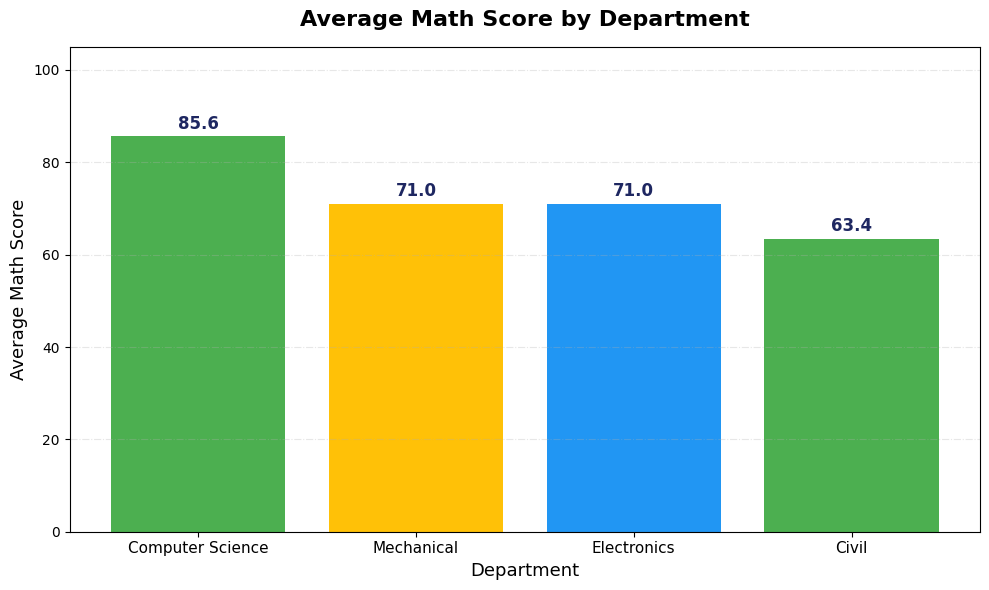

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(result['department'], result['avg_math'], color=['#4CAF50', '#FFC107', '#2196F3'])

for bar in bars:
    height = bar.get_height()
    # get_height() returns the bar's height (= the avg_math value)

    ax.text(
        bar.get_x() + bar.get_width() / 2,   # x position: center of the bar
        height + 0.8,                         # y position: just above the bar top
        f'{height:.1f}',                      # text: height formatted to 1 decimal place
        ha='center', va='bottom',             # horizontal/vertical alignment
        fontsize=12, fontweight='bold',       # font styling
        color='#1E2761'                       # navy text color
    )

# Chart labels and title formatting
ax.set_title("Average Math Score by Department", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Department", fontsize=13)
ax.set_ylabel("Average Math Score", fontsize=13)
ax.set_ylim(0, 105)                          # y-axis from 0 to 105 so labels above bars fit

# Tick and grid customization
ax.tick_params(axis='x', labelsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='-.') # axis='y' adds horizontal gridlines only

plt.tight_layout()                            # Adjusts spacing to prevent label clipping
plt.show()


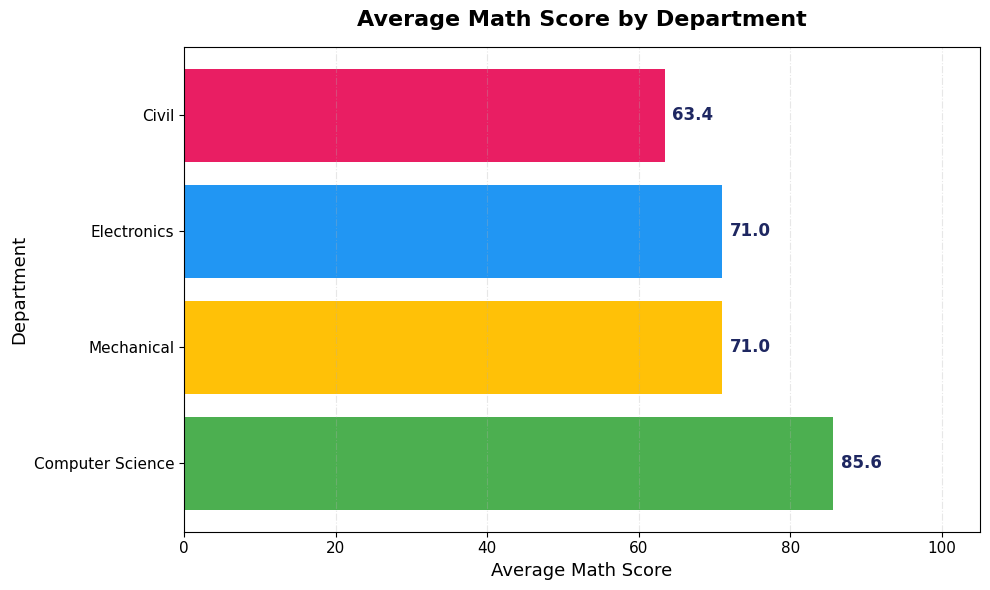

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))

# Use ax.barh for a horizontal bar chart
bars = ax.barh(result['department'], result['avg_math'], color=['#4CAF50', '#FFC107', '#2196F3', '#E91E63'])

for bar in bars:
    width = bar.get_width()
    # get_width() returns the horizontal bar's length (= the avg_math value)

    ax.text(
        width + 1.0,                         # x position: just to the right of the bar end
        bar.get_y() + bar.get_height() / 2,   # y position: center of the horizontal bar
        f'{width:.1f}',                      # text: formatted to 1 decimal place
        ha='left', va='center',               # left-align text, center vertically
        fontsize=12, fontweight='bold',       # font styling
        color='#1E2761'                       # navy text color
    )

# Chart labels and title formatting
ax.set_title("Average Math Score by Department", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Average Math Score", fontsize=13)
ax.set_ylabel("Department", fontsize=13)
ax.set_xlim(0, 105)                          # x-axis from 0 to 105 so labels fit next to bars

# Tick and grid customization
ax.tick_params(axis='both', labelsize=11)
ax.grid(axis='x', alpha=0.3, linestyle='-.') # axis='x' adds vertical gridlines only

plt.tight_layout()                            # Adjusts spacing to prevent label clipping
plt.show()